<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection

 **Anomaly Detection**

Goal:
Detect unusual or rare data points (outliers) without using labels.

Examples:
- Credit card fraud
- Network intrusion
- Machine faults
- Medical abnormalities


**Gaussian Anomaly Detection (Andrew Ng)**

Idea:
- Assume each feature follows a Gaussian (Normal) distribution.
- Estimate the distribution using the training data.
- Compute the probability of a new example.
- If the probability is below a threshold (ε), classify it as an anomaly.

Parameters:
μ (Mean) : Average value of a feature.

σ² (Variance) : Measures how spread out the feature values are.

ε (Epsilon): Probability threshold.

If P(x) < ε → Anomaly

Else → Normal

Assumption : Features are independent, so:

P(x) = P(x₁) × P(x₂) × ... × P(xₙ)


**Isolation Forest (scikit-learn)**

Idea:
> Instead of fitting a probability distribution,
randomly split the data until each point is isolated.

- Outliers are isolated quickly.
- Normal points require more splits.

```
Output Labels:
1  → Normal
-1 → Anomaly
```
Important Parameter:

**contamination :** Expected proportion of anomalies in the dataset.

Example:

model = IsolationForest(contamination=0.01)


Summary

Gaussian Anomaly Detection:

- Probability-based

- Uses μ, σ² and ε

- Assumes Gaussian distribution

Isolation Forest:
- Tree-based
- No Gaussian assumption
- Works well on real-world datasets
- Commonly used in practice

We'll use Isolation Forest, because it's the most common anomaly detection algorithm in practice.


## Create Dataset

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
X, y = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.2,
    random_state=42
)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [3]:
import numpy as np

# create rando outliers

outliers = np.array([
    [5, 5],
    [6, 6],
    [-5, -4],
    [4, -5]
])

# combine with existing data

X_anomaly = np.vstack((X_scaled, outliers))

## Plot data:

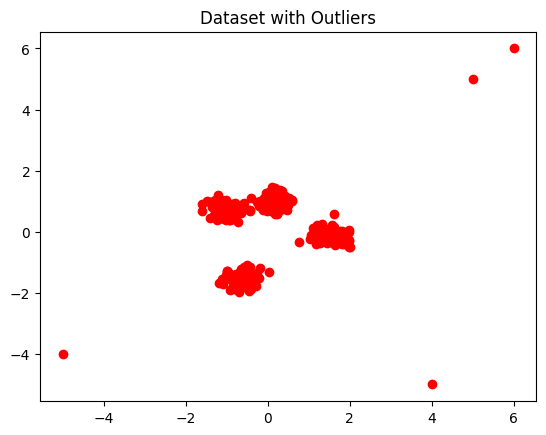

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X_anomaly[:,0], X_anomaly[:,1], color='red')
plt.title("Dataset with Outliers")
plt.show()

## Isolation Forest

In [9]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.01,
    random_state=42
)

labels = model.fit_predict(X_anomaly)

```contamination=0.01```

means:

> I expect about 1% of my data to be anomalies.

## What are the lables:

In [10]:
print(labels)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1

Meaning:

1 → Normal

-1 → Anomaly

## Plot the detected anomalies

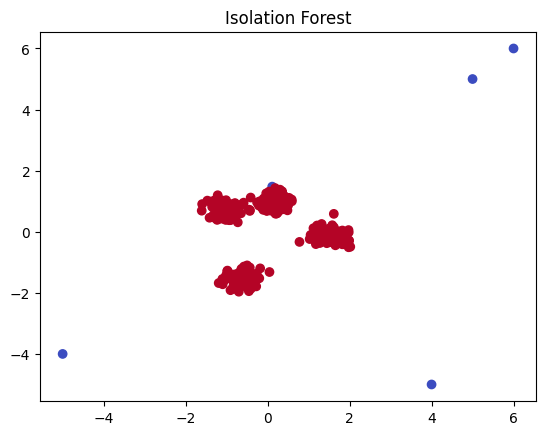

In [11]:
plt.scatter(
    X_anomaly[:,0],
    X_anomaly[:,1],
    c=labels,
    cmap="coolwarm"
)

plt.title("Isolation Forest")
plt.show()

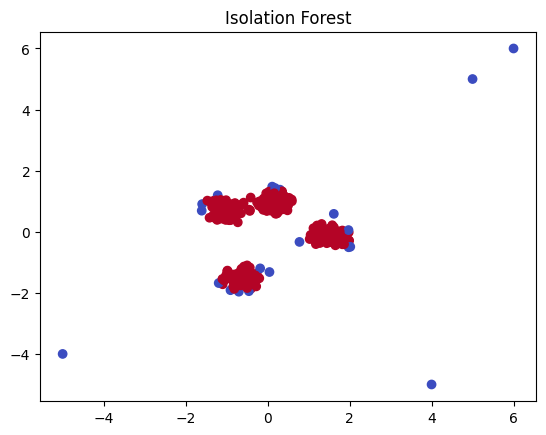

In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

labels = model.fit_predict(X_anomaly)
plt.scatter(
    X_anomaly[:,0],
    X_anomaly[:,1],
    c=labels,
    cmap="coolwarm"
)

plt.title("Isolation Forest")
plt.show()

The contamination parameter is literally just a threshold valve that you control:

If you set contamination=0.05, you are telling the model: "Hey, take the top 5% of the data points with the absolute highest anomaly scores and label them as -1 (anomaly)."

If you increase it to contamination=0.15, the model blindly opens the valve wider and grabs the top 15% highest-scoring points.

The model isn't magically finding "more" anomalies; it's just lowering its strictness because you told it to be more paranoid!

**What if you don't know the anomaly rate?** (The Blind Strategy)


In the real world, you almost never know how much of your data is an anomaly ahead of time. Here is the exact engineering framework you should use to solve this:

Approach A: Use the "auto" setting
In scikit-learn, you don't have to guess a percentage. You can set:

Python
```
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination='auto')
```

When you use 'auto', the library uses a mathematically defined threshold based on the original paper's logic. It looks for the natural boundary where the average path length of the trees shifts from "normal" to "abnormally short." It flags only the points that are statistically distinct outliers, without forcing a fixed percentage box.

Approach B: Inspect the Raw Anomaly Scores (The Decision Curve)
Don't let the model make the final decision for you! Instead of looking at the predicted labels (1 or -1), pull the raw anomaly scores using .score_samples(X).

Get the scores for all your data points.

Plot a histogram of those scores.

Look for a natural split!